<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Crypto_Price_Predictor_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

بدء تدريب نموذج التوقعات...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0395
Epoch 2/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0160
Epoch 3/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0163
Epoch 4/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0161
Epoch 5/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0158
Epoch 6/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0155
Epoch 7/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0158
Epoch 8/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0154
Epoch 9/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0154
Epoch 10/10
989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0151
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


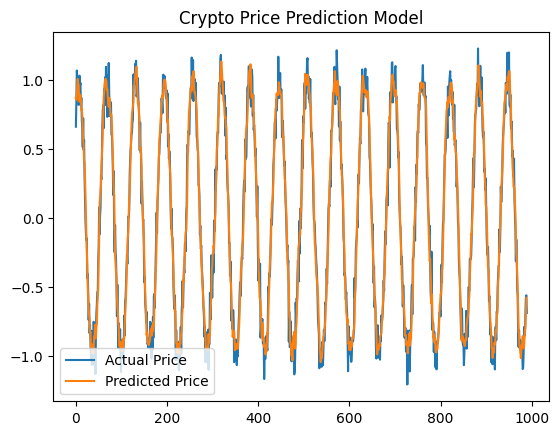

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. توليد بيانات تجريبية (محاكاة لأسعار عملة ما)
data = np.sin(np.linspace(0, 100, 1000)) + np.random.normal(0, 0.1, 1000)

# 2. تحضير البيانات لتدريب الـ LSTM (تحويلها لمجموعات متتالية)
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        X.append(dataset[i:(i+look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)

look_back = 10
X, y = create_dataset(data, look_back)
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

# 3. بناء شبكة LSTM العصبية
model = Sequential([
    LSTM(50, input_shape=(1, look_back)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
print("بدء تدريب نموذج التوقعات...")
model.fit(X, y, epochs=10, batch_size=1, verbose=1)

# 4. رسم النتائج والتوقعات
predictions = model.predict(X)
plt.plot(data[look_back:], label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.legend()
plt.title("Crypto Price Prediction Model")
plt.show()